#  Pandemic Simulation Homework 

###  Bus 36109 "Advanced Decision Modeling with Python", Don Eisenstein
Don Eisenstein &copy; Copyright 2023, University of Chicago 

---


We model the spread of a pandemic with a simulation.   Our model will assume a fixed number of people for the length of the simulation.  Each day a person is in one of five states of health:

### States of our model

- (S) **S**usceptible to catching it when exposed.  Currently healthy, does not have, and never has had the disease.
- (C) **C**ontagious to others.  Currently has the disease but is aymptomatic.
- (H) Currently has the disease and knows it, has tested positive and/or is showing symptoms, and so is quarantined at **H**ome or **H**ospitalized and so is no longer considered a risk to pass the disease onto others.  We assume no capacity limits at the Hospital.
- (I) Has survived the disease and is now for this disease is considered **I**mmune and is assumed to remain so.  Those in this group are not quarantined and thus are active in the population.
- (D) **D**eceased

## Interpreting the States and Transitions

An individual would not be able to discern between being in state (S) or (C), and may have had the disease without symptoms, recovered, and be in state (I).  That is, we are studying how a disease will move through a population, even though a particular individual may not know what state they are in.  

So those in (C) will either be tested or exhibit symptoms and transition to (H), or unbeknowst to themselves will fight off the disease and transition directly to (I) where they are no longer contageous.  Those in (H) will either beat the disease and transition to (I) or succumb and transition to (D).

Each *day* we model that a person will transistion from each of these states to possibly some others or back to its current state.  The following transitions are possible:

From S, one can only remain in S or move to C
- `P_S_S` = Probability of remaining in S, healthy without contracting the disease 
- `P_S_C` = Probability of moving from S to C, contracting the disease

From C, one can only remain in C or move to H or I 
- `P_C_C` = Probability of remaining in C,  with the disease but is not aware or asymptomatic
- `P_C_H` = Probability of moving from C to H, moving from asymptomatic to aware and/or symptomatic 
- `P_C_I` = Probability of moving from C to I, fighting off the disease and becoming immune 

From H, one can only remain in H or move to D or I 
- `P_H_H` = Probability of remaining in H, continuing to test positive and/battling the disease 
- `P_H_D` = Probability of moving from H to D, succumbing to the disease 
- `P_H_I` = Probability of moving from H to I, successfully fighting off the disease and becoming immune

Once in I or D one remains there
- `P_I_I` = Probability of remaining in I is 1 
- `P_D_D` = Probability of remaining in D is 1 


<blockquote>

##### A crude but perhaps helpful diagram of all possible transitions (I will post an image of this diagram on canvas if it fails to render for you):    
    
              -- >               < -- 
              |   (H) ------> (D)    | 
              -- > ^ \           < --
                   |   \
                   |     >
         (S) ---> (C) ---> (I)
         ^ ^      ^ ^      ^ ^
         | |      | |      | | 
         ---      ---      --- 
    
</blockquote>

## Modeling the transition probabilities

The values of the transition probabilities model how much contact the population has with each other, whether precations like masking or social distancing are being used, the characteristics of the disease (how contageous, how long one remains contageous), and the severity of the disease and viability of our health-care system (how many survive once symptomatic).

### Transitioning from Susceptible State S

We will consider the following definitions and factor to help define how the population moves from S to C.

- `prop_C` The proportion of the population that is not quarantined that is currently Contagious:

$$
\text{Prop}_\text{Contagious} \, = \, 
\frac{\text{\# Contagious}}{\text{\# Contagious + \# Susceptible + \# Immune}}
$$

-  `f` An exposure factor in (0,1), which models how contangious the disease is *and* how many interactions a person has with contagious people.  

We then define:

`P_S_C` =  `f` * `prop_C`

So as the proportion of the population that is contagious increases (`prop_C`), the probability of a Susceptible (S) person moving to Contagious (C) increases.  The `f` factor models the chance each day that such an encounter results in catching the disease and how many Contagious people a Susceptible person encounters in a day. 

So, a small value of `f` models that people are self-isolating, wearing masks, and/or that the disease is not very contagious.  Conversely, a large value of `f` models that people are interacting without precations on a daily basis with many others and/or that the disease is very contagious.  The `f` factor would be studied and estimated for various populations (a dense city vs sparse countryside) and various diseases (airborne and highly contagious or requires intimate contact). 

Furthermore, a person who is in state S must either remain in S or transition to C, and so we must have:

`P_S_S` =  1 - (`f` * `prop_C`)


### Base Run parameters:

You will make just one run with a fixed set of parameters.  In general, one can then investigate the impact of the disease on the public by changing various parameters that would reflect public health measures, etc.

`SIM_LENGTH` = 200    # Number of days to simulation

`POPULATION_SIZE` = 1000  # The fixed population size during the simulation

`NUMBER_INITIALLY_CONTAGIOUS` = 40   # This is the number starting in State (C), the rest of population begins in state (S)

The `f` factor that helps govern Transitioning from S
- `f` = 0.2

Tranistioning from C
- `P_C_C` = 0.90
- `P_C_H` = 0.05
- `P_C_I` = 1 -`P_C_C` - `P_C_H` 

Tranistioning from H
- `P_H_H` = 0.80
- `P_H_I` = 0.16
- `P_H_D` = 1 - `P_H_H` - `P_H_I` 

Tranistioning from I and D
- `P_D_D` = 1 
- `P_I_I` = 1 



### Some potentially helpful hints and reminders

####  Numpy's `random.choice`

This method makes it easy to choose between a set of alternatives with any set of probabilites that sum to 1.0

`dinner = np.random.choice( ["pizza", "burrito", "cottage cheese and peaches"], p=[0.70, 0.27, 0.03] )`

#### SimPy tidbits

- Use `env.now` to return the current simulation clock time
- Use `server.count` to return the number of Entities currently in process at the Resource object `server` 
- Use `self.count` in a Source or Entity Class block to return the number of the Entity.  Counting begins at 0 

#### Making a plot with multiple lines, colors, and legend


In [1]:
# import numpy as np
# import matplotlib.pyplot as plt

# density_X = [100, 200, 300, 400] 
# drivers_Y = [5,8,9,11] 
# walkers_Y = [20, 18, 14, 10] 

# fig = plt.figure()
# plt.plot(density_X, drivers_Y, color="red", label="drivers")
# plt.plot(density_X, walkers_Y, color="blue", label="walkers")
# plt.ylabel('Number')
# plt.xlabel('Density')

# plt.legend();
# plt.show()

### Questions 

1. Make a Simulation run with the Base Run Parameters Specified above.

   - Create a line plot with the number in states (S), (C), (I), (D) plotted over the simulated days.  So your x-axis is "Days" and your y-axis is "Number". 
   -  Color your plot lines as follows and provide a legend:
       - S: blue 
       - C: red
       - I: green
       - D: brown
     
2. Print out how many at the end of the simulation: never caught the disease? caught & survived?succumbed?

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import simpy
from simpy_helpers import Entity, Resource, Source, Stats

In [3]:
# Parameters
SIM_LENGTH = 200
POPULATION_SIZE = 1000
NUMBER_INITIALLY_CONTAGIOUS = 40

f_factor = 0.2

P_C_C = 0.90
P_C_H = 0.05
P_C_I = 1 - P_C_C - P_C_H   # 0.05

P_H_H = 0.80
P_H_I = 0.16
P_H_D = 1 - P_H_H - P_H_I   # 0.04

P_I_I = 1.0
P_D_D = 1.0

prop_C = NUMBER_INITIALLY_CONTAGIOUS / POPULATION_SIZE

In [4]:
# Resources
class Susceptible(Resource):
    def service_time(self, entity):
        return 1
    def next_state(self, entity):
        
        # Compute prop_C
        n_c = states["C"].count
        n_s = states["S"].count
        n_i = states["I"].count
        active = n_c + n_s + n_i
        prop_C = n_c / active if active > 0 else 0
        p_s_c = f_factor * prop_C

        # Choose next_state
        return np.random.choice(["S", "C"], p=[1 - p_s_c, p_s_c])

class Contagious(Resource):
    def service_time(self, entity):
        return 1
    def next_state(self, entity):
        return np.random.choice(["C", "H", "I"], p=[P_C_C, P_C_H, P_C_I])

class Hospitalized(Resource):
    def service_time(self, entity):
        return 1
    def next_state(self, entity):
        return np.random.choice(["H", "I", "D"], p=[P_H_H, P_H_I, P_H_D])

class Immune(Resource):
    def service_time(self, entity):
        return 1
    def next_state(self, entity):
        return "I"

class Deceased(Resource):
    def service_time(self, entity):
        return 1
    def next_state(self, entity):
        return "D"

In [10]:
# Entity
class Person(Entity):
    last_recorded_day = 0
    def process(self):
        
        for i in range(SIM_LENGTH + 1):

            # Spend 1 day at the current state's Resource
            resource = states[self.attributes['state']]
            yield self.wait_for_resource(resource)
            yield self.process_at_resource(resource)

            # Record population statistics
            if env.now > Person.last_recorded_day:

                # Makes sure pop_stat is only updated once per day
                Person.last_recorded_day = env.now
                
                pop_stat["S"].append(susceptible.count)
                pop_stat["C"].append(contagious.count)
                pop_stat["H"].append(hospitalized.count)
                pop_stat["I"].append(immune.count)
                pop_stat["D"].append(deceased.count)

            self.release_resource(resource)

            # Resource decides the next state
            next_state = resource.next_state(self)
            self.attributes['state'] = next_state

# Source
class PersonSource(Source):
    def interarrival_time(self):
        return 0

    def build_entity(self):
        attributes = {}
        if self.count < NUMBER_INITIALLY_CONTAGIOUS:
            attributes['state'] = 'C'
        else:
            attributes['state'] = 'S'
        return Person(env, attributes)

In [11]:
env = simpy.Environment()

susceptible = Susceptible(env, capacity=POPULATION_SIZE)
contagious = Contagious(env, capacity=POPULATION_SIZE)
hospitalized = Hospitalized(env, capacity=POPULATION_SIZE)
immune = Immune(env, capacity=POPULATION_SIZE)
deceased = Deceased(env, capacity=POPULATION_SIZE)

states = {
    "S": susceptible,
    "C": contagious,
    "H": hospitalized,
    "I": immune,
    "D": deceased,
}

pop_stat = {
    "S": [], 
    "C": [], 
    "H": [], 
    "I": [], 
    "D": []
}

In [12]:
population = PersonSource(env, number=POPULATION_SIZE)
env.process(population.start(debug=False))
env.run(until=SIM_LENGTH + 1)

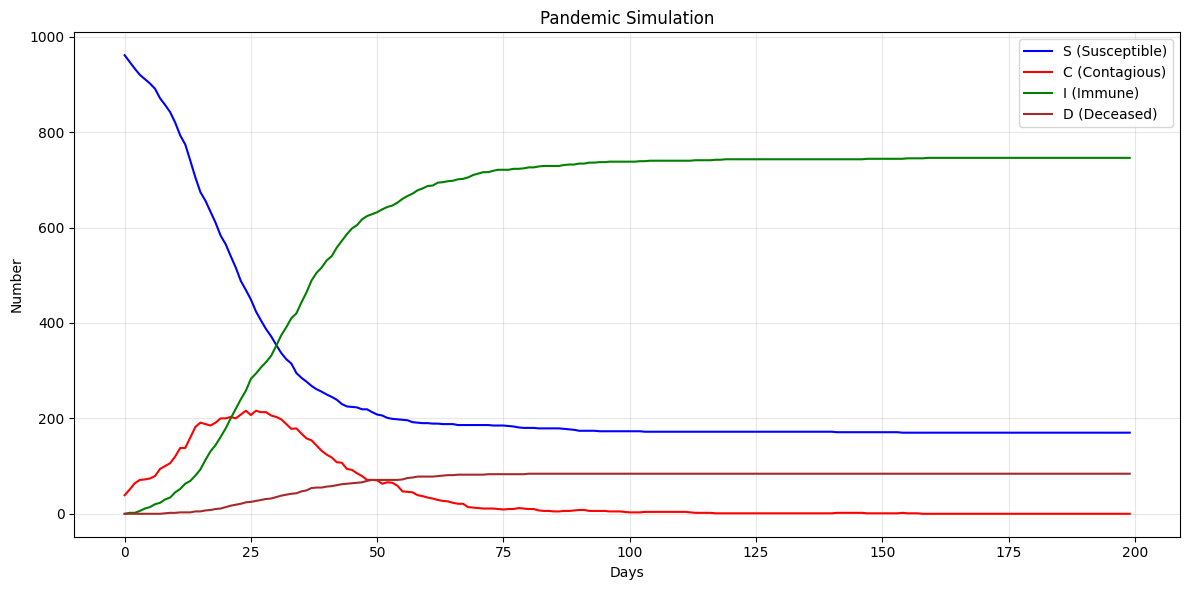

In [13]:
days = list(range(len(pop_stat["S"])))

plt.figure(figsize=(12, 6))
plt.plot(days, pop_stat["S"], color="blue", label="S (Susceptible)")
plt.plot(days, pop_stat["C"], color="red", label="C (Contagious)")
plt.plot(days, pop_stat["I"], color="green", label="I (Immune)")
plt.plot(days, pop_stat["D"], color="brown", label="D (Deceased)")
plt.xlabel("Days")
plt.ylabel("Number")
plt.title("Pandemic Simulation")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()